In [3]:
from google.colab import files
uploaded = files.upload()

Saving movie-ratings.txt to movie-ratings (1).txt


In [4]:
import os
os.listdir()

['.config', 'movie-ratings.txt', 'movie-ratings (1).txt', 'sample_data']

In [5]:
import pandas as pd

column_names = ["userId", "movieId", "movieCategoryId", "reviewId", "movieRating", "reviewDate"]

ratings = pd.read_csv(
    "movie-ratings.txt",
    sep=",",
    names=column_names,
    engine="python"
)

ratings.head()

,userId,movieId,movieCategoryId,reviewId,movieRating,reviewDate
0,1,1,1,1,5,2000-07-12
1,2,1,1,2,5,2000-07-12
2,3,1,1,3,5,2000-07-12
3,4,1,1,4,4,2000-07-12
4,5,1,1,5,4,2000-07-12


In [6]:
num_users = ratings['userId'].nunique()
num_movies = ratings['movieId'].nunique()
num_ratings = len(ratings)

print("Number of users:", num_users)
print("Number of movies:", num_movies)
print("Number of ratings:", num_ratings)

Number of users: 17615
Number of movies: 16121
Number of ratings: 72665


In [7]:
sparsity = 1 - (num_ratings / (num_users * num_movies))
print("Sparsity:", sparsity)

Sparsity: 0.9997441115684126


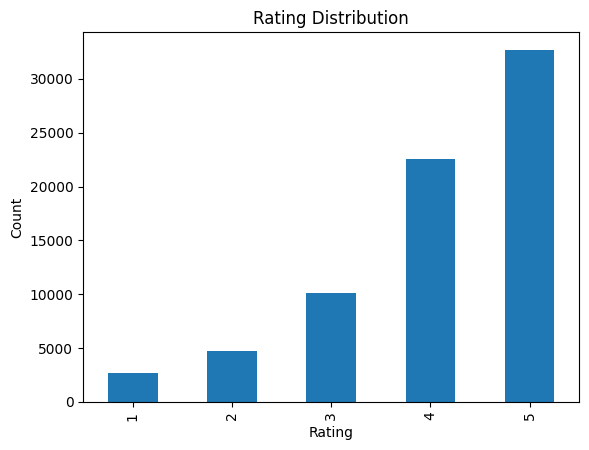

In [8]:
import matplotlib.pyplot as plt

ratings['movieRating'].value_counts().sort_index().plot(kind='bar')

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

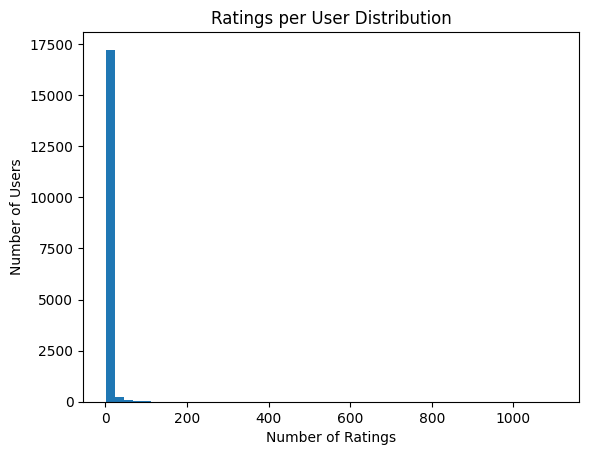

In [9]:
ratings_per_user = ratings.groupby('userId')['movieRating'].count()

ratings_per_user.plot(kind='hist', bins=50)

plt.title("Ratings per User Distribution")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.show()

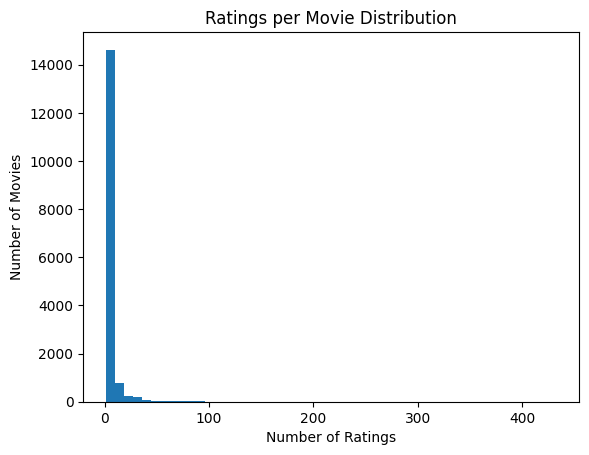

In [10]:
ratings_per_movie = ratings.groupby('movieId')['movieRating'].count()

ratings_per_movie.plot(kind='hist', bins=50)

plt.title("Ratings per Movie Distribution")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Movies")
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
import numpy as np

train, test = train_test_split(ratings, test_size=0.2, random_state=42)

global_avg = train['movieRating'].mean()

predictions = np.full(len(test), global_avg)

actual = test['movieRating'].values

rmse = np.sqrt(np.mean((predictions - actual) ** 2))

mae = np.mean(np.abs(predictions - actual))

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 1.0820577055559708
MAE: 0.8351421604406448


In [12]:
movie_avg = train.groupby('movieId')['movieRating'].mean()

item_predictions = test['movieId'].map(movie_avg)

item_predictions = item_predictions.fillna(global_avg)

actual = test['movieRating'].values
item_predictions = item_predictions.values

item_rmse = np.sqrt(np.mean((item_predictions - actual) ** 2))
item_mae = np.mean(np.abs(item_predictions - actual))

print("Item-Based CF RMSE:", item_rmse)
print("Item-Based CF MAE:", item_mae)

Item-Based CF RMSE: 1.0056000443210746
Item-Based CF MAE: 0.7463108353084581


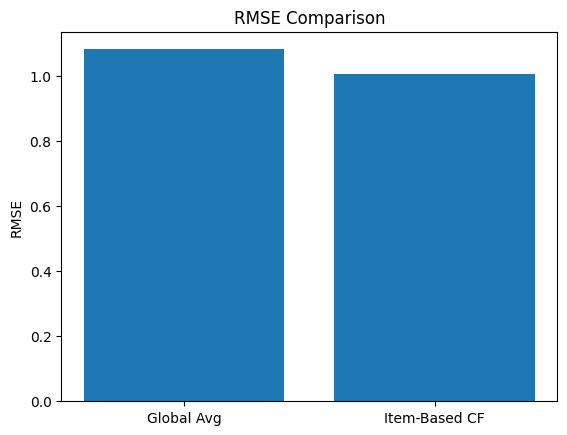

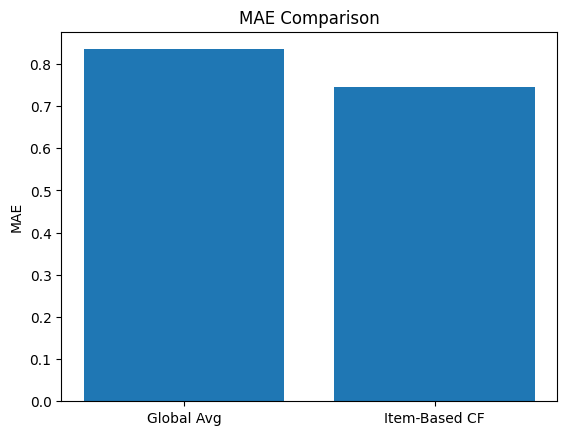

In [13]:
import matplotlib.pyplot as plt

models = ['Global Avg', 'Item-Based CF']
rmse_values = [1.082, 1.006]
mae_values = [0.835, 0.746]

plt.bar(models, rmse_values)
plt.title("RMSE Comparison")
plt.ylabel("RMSE")
plt.show()

plt.bar(models, mae_values)
plt.title("MAE Comparison")
plt.ylabel("MAE")
plt.show()